<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/Random%20Forest%20LOEO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RANDOM FOREST

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Project/Project1/processed/csi_feature_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (53016, 9)


,mean_amp,std_amp,var_amp,max_amp,min_amp,antenna_corr,subcarrier_corr,label,environment
0,2.488678,0.579163,0.335430,3.975699,0.559248,0.542688,0.815294,1,processed_channe14_LOS_cluster1.hdf5
1,2.488807,0.575728,0.331463,3.883031,0.569000,0.550662,0.816676,1,processed_channe14_LOS_cluster1.hdf5
2,2.489268,0.579336,0.335631,3.982258,0.566464,0.538711,0.818489,1,processed_channe14_LOS_cluster1.hdf5
3,2.489166,0.579777,0.336141,4.024301,0.540201,0.526773,0.818690,1,processed_channe14_LOS_cluster1.hdf5
4,2.489647,0.577595,0.333616,3.971815,0.537490,0.534651,0.819378,1,processed_channe14_LOS_cluster1.hdf5


Remove the Label and Environment feature from training data and group dataset according to environment

In [ ]:
X = df.drop(columns=["label", "environment"])
y = df["label"]

groups = df["environment"]

Leave One Environment Out LOEO

In [ ]:
logo = LeaveOneGroupOut()

Loop to test all environment one by one (in each iteration new model gets created so no data leakage)

In [ ]:
results = []

for train_idx, test_idx in logo.split(X, y, groups):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    test_environment = groups.iloc[test_idx].unique()[0]

    # Feature scaling
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    results.append((test_environment, acc))

    print("Test Environment:", test_environment)
    print("Accuracy:", acc)
    print("---------------------")

Test Environment: processed_channe14_LOS_cluster1.hdf5
Accuracy: 0.9259352563295126
---------------------
Test Environment: processed_channe14_LOS_cluster2.hdf5
Accuracy: 0.8498366423724554
---------------------
Test Environment: processed_channe14_LOS_cluster3.hdf5
Accuracy: 1.0
---------------------
Test Environment: processed_channe14_LOS_cluster4.hdf5
Accuracy: 1.0
---------------------
Test Environment: processed_channe14_NLOS_cluster1.hdf5
Accuracy: 0.9998299319727891
---------------------
Test Environment: processed_channe14_NLOS_cluster2.hdf5
Accuracy: 1.0
---------------------
Test Environment: processed_channe14_NLOS_cluster3.hdf5
Accuracy: 0.9344049779621467
---------------------
Test Environment: processed_channe14_NLOS_cluster4.hdf5
Accuracy: 0.9963692946058091
---------------------
Test Environment: processed_channe14_NLOS_cluster5.hdf5
Accuracy: 0.9994821336095288
---------------------


Sorting environments on the basis of difficulty in prediction

In [ ]:
results_df = pd.DataFrame(results, columns=["Environment", "Accuracy"])

results_df = results_df.sort_values(by="Accuracy")

print(results_df)

                             Environment  Accuracy
1   processed_channe14_LOS_cluster2.hdf5  0.849837
0   processed_channe14_LOS_cluster1.hdf5  0.925935
6  processed_channe14_NLOS_cluster3.hdf5  0.934405
7  processed_channe14_NLOS_cluster4.hdf5  0.996369
8  processed_channe14_NLOS_cluster5.hdf5  0.999482
4  processed_channe14_NLOS_cluster1.hdf5  0.999830
3   processed_channe14_LOS_cluster4.hdf5  1.000000
2   processed_channe14_LOS_cluster3.hdf5  1.000000
5  processed_channe14_NLOS_cluster2.hdf5  1.000000


Average accuracy

In [ ]:
avg_accuracy = results_df["Accuracy"].mean()

print("Average LOEO Accuracy:", avg_accuracy)

Average LOEO Accuracy: 0.9673175818724713


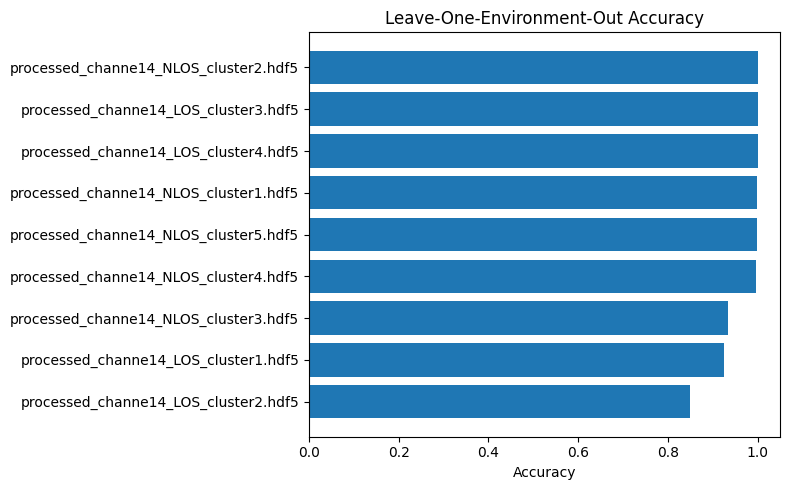

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(results_df["Environment"], results_df["Accuracy"])

plt.xlabel("Accuracy")
plt.title("Leave-One-Environment-Out Accuracy")

plt.tight_layout()

plt.show()